
# Primera Entrega Proyecto de Investigación

### Introducción

Este notebook presenta un análisis exploratorio del dataset de personas registradas en SISBÉN, con el objetivo de comprender su estructura, identificar variables relevantes y analizar preliminarmente condiciones socioeconómicas y educativas que puedan aportar al estudio de brechas territoriales. A partir de este análisis se busca reconocer patrones, calidad de los datos y posibles transformaciones necesarias para integrar posteriormente esta información con otras fuentes del proyecto, como conectividad e indicadores educativos.

## Descripción de los Datos
### Carga de las Librerias

In [0]:
from pyspark.sql import functions as F
from pyspark.sql import types as T
import matplotlib.pyplot as plt

### Carga de Datos
En esta sección se carga el dataset desde SQL en un solo DataFrame para facilitar el análisis.

In [0]:
df = spark.sql("SELECT * FROM workspace.proyecto.vista_ndp")
df_sisben = spark.table("workspace.proyecto.vista_ndp")

## Vista Preliminar
Se visualizan algunos registros para verificar que la carga desde SQL se haya realizado correctamente y para familiarizarse con la estructura del dataset.

In [0]:
display(df_sisben.limit(5))

cod_mpio,H_5,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,I14,I15,Grupo,Nivel,Clasificacion,ZONA,llave,CORTE,HOGAR,ORDEN,FEX,PER001,PER002,PER003,PER004,PER005,PER005B,PER006,PER006B,PER007,PER008,PER009,PER010,PER011,PER012,PER013,PER014,PER015,PER016,PER017,PER018,PER019,PER020
23168,1,1,0,0,0,0,0,0,1,0,0,1,1,1,1,0,B,7,B7,2,359,SIV_2022,1,1,3.062267658,1,5,1,2,9,99,2,99,3,2,9,9,9,9,9,9,1,2,2,2,2,10
25258,0,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,D,2,D2,2,556,SIV_2022,1,1,2.37,1,6,1,2,9,99,2,99,3,2,9,9,9,9,9,9,1,2,2,2,2,10
25307,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,A,3,A3,2,1281,SIV_2022,1,3,2.3903688525,2,1,3,2,9,99,1,1,0,2,9,9,9,9,2,1,9,9,9,9,9,99
54660,1,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,A,4,A4,2,780,SIV_2022,1,3,2.0981461287,1,6,12,2,9,99,2,99,3,2,9,9,9,9,9,9,2,2,1,2,5,99
17088,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,B,7,B7,1,376,SIV_2022,2,2,2.4245614035,2,2,3,2,9,99,1,1,3,2,9,9,2,2,9,9,1,1,2,9,4,99


##Estructura y Tipos de Datos
Se revisan las columnas y sus tipos de datos para identificar variables relevantes y reconocer cuáles requieren limpieza o transformación.

In [0]:
df_sisben.printSchema()

root
 |-- cod_mpio: long (nullable = true)
 |-- H_5: long (nullable = true)
 |-- I1: long (nullable = true)
 |-- I2: long (nullable = true)
 |-- I3: long (nullable = true)
 |-- I4: long (nullable = true)
 |-- I5: long (nullable = true)
 |-- I6: long (nullable = true)
 |-- I7: long (nullable = true)
 |-- I8: long (nullable = true)
 |-- I9: long (nullable = true)
 |-- I10: long (nullable = true)
 |-- I11: long (nullable = true)
 |-- I12: long (nullable = true)
 |-- I13: long (nullable = true)
 |-- I14: long (nullable = true)
 |-- I15: long (nullable = true)
 |-- Grupo: string (nullable = true)
 |-- Nivel: long (nullable = true)
 |-- Clasificacion: string (nullable = true)
 |-- ZONA: long (nullable = true)
 |-- llave: long (nullable = true)
 |-- CORTE: string (nullable = true)
 |-- HOGAR: long (nullable = true)
 |-- ORDEN: long (nullable = true)
 |-- FEX: string (nullable = true)
 |-- PER001: long (nullable = true)
 |-- PER002: long (nullable = true)
 |-- PER003: long (nullable = true)
 |

## Descripción General del Contenido
El dataset contiene información individual de personas registradas en SISBÉN, incluyendo variables territoriales, de clasificación socioeconómica y de privación social. Este conjunto de datos permite caracterizar condiciones de vulnerabilidad de la población y generar insumos útiles para el análisis del proyecto.
Entre las columnas más relevantes para este análisis se encuentran:
* cod_mpio: código del municipio, útil para realizar agregaciones y análisis territoriales.
* h_5: indicador proxy de pobreza multidimensional (IPM).
* i1: privación por bajo logro educativo.
* i3: privación por inasistencia escolar.

## Descripción Detallada de los Datos
### Número de Columnas y Nombres

In [0]:
print("Número de columnas:", len(df_sisben.columns))
df_sisben.columns

Número de columnas: 48


['cod_mpio',
 'H_5',
 'I1',
 'I2',
 'I3',
 'I4',
 'I5',
 'I6',
 'I7',
 'I8',
 'I9',
 'I10',
 'I11',
 'I12',
 'I13',
 'I14',
 'I15',
 'Grupo',
 'Nivel',
 'Clasificacion',
 'ZONA',
 'llave',
 'CORTE',
 'HOGAR',
 'ORDEN',
 'FEX',
 'PER001',
 'PER002',
 'PER003',
 'PER004',
 'PER005',
 'PER005B',
 'PER006',
 'PER006B',
 'PER007',
 'PER008',
 'PER009',
 'PER010',
 'PER011',
 'PER012',
 'PER013',
 'PER014',
 'PER015',
 'PER016',
 'PER017',
 'PER018',
 'PER019',
 'PER020']

Este dataset contiene información sociodemográfica, territorial y de condiciones de vulnerabilidad de personas registradas en SISBÉN en Colombia.
Está compuesto por variables de tipo numérico y categórico, organizadas en las siguientes dimensiones:
### 1. Identificación Territorial
Variables que permiten ubicar geográficamente cada registro:
- cod_mpio: código del municipio.
- zona: zona asociada al registro.
  - 1 = Cabecera
  - 2 = Centro poblado / rural disperso

### 2. Indicadores de Pobreza y Privación (IPM Proxy)
Variables que permiten identificar condiciones de pobreza multidimensional y distintas privaciones específicas. En este caso, se trata de variables binarias, donde 0 indica ausencia de la privación y 1 indica presencia de la privación:
- h_5: indicador proxy de pobreza multidimensional (IPM).
- i1: privación por bajo logro educativo.
- i2: privación por analfabetismo.
- i3: privación por inasistencia escolar.
- i4: privación por rezago escolar.
- i5: privación por barreras a servicios para cuidado de la primera infancia.
- i6: privación por trabajo infantil.
- i7: privación por desempleo de larga duración.
- i8: privación por trabajo informal.
- i9: privación por no aseguramiento en salud.
- i10: privación por barreras de acceso a servicios de salud.
- i11: privación por falta de acceso a fuentes de agua mejorada.
- i12: privación por inadecuada eliminación de excretas.
- i13: privación por material inadecuado de pisos.
- i14: privación por material inadecuado de paredes exteriores.
- i15: privación por hacinamiento crítico.

### 3. Clasificación Socioeconómica SISBÉN
Variables que describen la clasificación oficial del registro dentro del sistema SISBÉN:
- grupo: grupo SISBÉN.
    - A = pobreza extrema
    - B = pobreza moderada
    - C = población vulnerable
    - D = población no pobre ni vulnerable
- nivel: nivel SISBÉN.
    - A1–A5
    - B1–B7
    - C1–C18
    - D1–D21
- clasificacion: clasificación SISBÉN.

### 4. Identificación del Hogar y la Persona
Variables que permiten distinguir vivienda, hogar y persona dentro de la base:
- llave: identificación de la vivienda.
- hogar: identificación del hogar.
- orden: identificación de la persona dentro del hogar.
- corte: corte de los datos.

### 5. Expansión y Representatividad
Variable asociada al peso estadístico del registro:
- fex: factor de expansión.

### 6. Características Demográficas y Familiares
Variables que describen características básicas de las personas registradas:
- per001: sexo.
  - 1 = Hombre
  - 2 = Mujer
- per002: edad.
  - 1 = 0 a 5 años
  - 2 = 6 a 11 años
  - 3 = 12 a 17 años
  - 4 = 18 a 28 años
  - 5 = 29 a 59 años
  - 6 = 60 años y más
- per003: parentesco con el jefe del hogar.
  - 1 = Jefe
  - 2 = Cónyuge o compañera(o)
  - 3 = Hijos
  - 4 = Nietos
  - 5 = Padres
  - 6 = Hermanos
  - 7 = Yerno o nuera
  - 8 = Abuelos
  - 9 = Suegros
  - 10 = Tíos
  - 11 = Sobrinos
  - 12 = Primos
  - 13 = Cuñados
  - 14 = Otros parientes
  - 15 = Empleado(a) de servicio doméstico
  - 16 = Pariente del servicio doméstico
  - 17 = Pensionista
  - 18 = Pariente de pensionista
  - 19 = No pariente
- per004: estado civil.
  - 1 = Unión libre o casado
  - 2 = Viudo, separado, divorciado o soltero
- per005: si el cónyuge vive en el hogar.
- per006: si el padre o la madre vive en el hogar.

### 7. Condiciones de Salud
Variables relacionadas con afiliación, enfermedad y acceso a servicios de salud:
- per007: seguridad social.
  - 0 = Ninguna
  - 1 = Contributivo
  - 2 = Especial
  - 3 = Subsidiado
  - 9 = No sabe

Variables de naturaleza binaria en las que 1 indica sí y 2 indica no.
- per008: enfermedad en los últimos 30 días.
- per009: acudió a una institución prestadora de servicios de salud.
- per010: fue atendido.
- per011: está embarazada.
- per012: ha tenido hijos.

### 8. Condiciones Educativas
Variables asociadas al acceso y trayectoria educativa de las personas:
- per015: sabe leer y escribir.
  - 1 = Sí
  - 2 = No
  - 9 = No aplica por flujo
- per016: actualmente estudia.
  - 1 = Sí
  - 2 = No
  - 9 = No aplica por flujo
- per017: nivel educativo.
  - 1 = Ninguno o preescolar
  - 2 = Básica primaria, secundaria o media
  - 3 = Técnico, tecnológico, universitario o posgrado
  - 9 = No aplica por flujo

### 9. Condiciones Laborales y de Protección Social
Variables relacionadas con actividad económica y cotización:
- per018: está cotizando a un fondo de pensiones.
  - 1 = Sí
  - 2 = No
  - 3 = Pensionado
  - 9 = No aplica por flujo
- per019: actividad principal en el último mes.
  - 1 = Sin actividad
  - 2 = Trabajando
  - 3 = Buscando trabajo
  - 4 = Estudiando
  - 5 = Oficios del hogar / rentista / jubilado o pensionado / incapacitado permanentemente
  - 9 = No aplica por flujo
- per020: posición ocupacional.
  - 1 = Empleado de empresa particular
  - 2 = Empleado del gobierno
  - 3 = Empleado doméstico
  - 4 = Profesional independiente
  - 5 = Trabajador independiente o por cuenta propia
  - 6 = Patrón o empleador
  - 7 = Trabajador de finca, tierra o parcela propia o en arriendo/aparcería/usufructo
  - 8 = Trabajador sin remuneración
  - 9 = Ayudante sin remuneración
  - 10 = Jornalero o peón
  - 99 = No aplica por flujo





## Exploración de Datos
### 1. Distribución de la población por grupo SISBÉN
Se analiza cómo se distribuyen los registros según el grupo SISBÉN para identificar qué segmentos concentran mayor proporción de la población en la base.

In [0]:
df_grupo = (
    df_sisben.groupBy("Grupo")
      .count()
      .orderBy("Grupo")
)

display(df_grupo)

Grupo,count
A,1868369
B,1650024
C,736613
D,210949


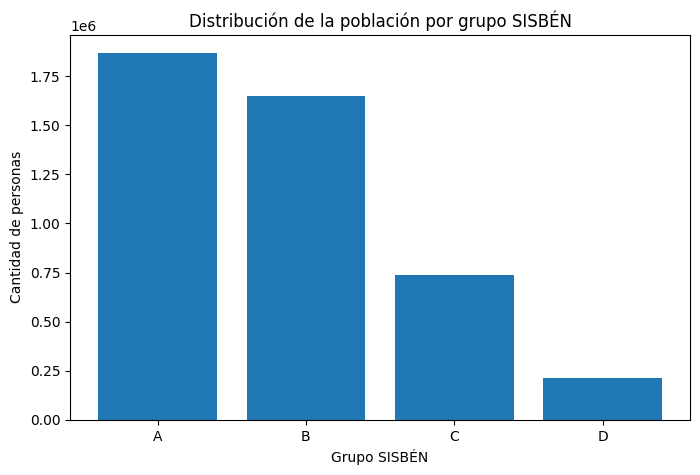

In [0]:
pdf_grupo = df_grupo.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf_grupo["Grupo"], pdf_grupo["count"])
plt.xlabel("Grupo SISBÉN")
plt.ylabel("Cantidad de personas")
plt.title("Distribución de la población por grupo SISBÉN")
plt.show()

### 2. Distribución por clasificación SISBÉN
Se observa la frecuencia de registros por clasificación, con el fin de entender la composición socioeconómica general del dataset.

In [0]:
df_clasificacion = (
    df_sisben.groupBy("Clasificacion")
      .count()
      .orderBy("Clasificacion")
)

display(df_clasificacion)

Clasificacion,count
A1,308440
A2,404934
A3,390068
A4,416518
A5,348409
B1,339982
B2,312512
B3,285511
B4,228619
B5,189861


### 3. Perfil etario de la población
Se explora la variable de edad para caracterizar la composición demográfica de las personas registradas.

In [0]:
df_edad = (
    df_sisben.groupBy("PER002")
      .count()
      .orderBy("PER002")
      .withColumn(
          "rango_edad",
          F.when(F.col("PER002") == 1, "0 a 5 años")
           .when(F.col("PER002") == 2, "6 a 11 años")
           .when(F.col("PER002") == 3, "12 a 17 años")
           .when(F.col("PER002") == 4, "18 a 28 años")
           .when(F.col("PER002") == 5, "29 a 59 años")
           .when(F.col("PER002") == 6, "60 años y más")
      )
)

display(df_edad)

PER002,count,rango_edad
1,495668,0 a 5 años
2,495882,6 a 11 años
3,459085,12 a 17 años
4,816789,18 a 28 años
5,1613933,29 a 59 años
6,584598,60 años y más


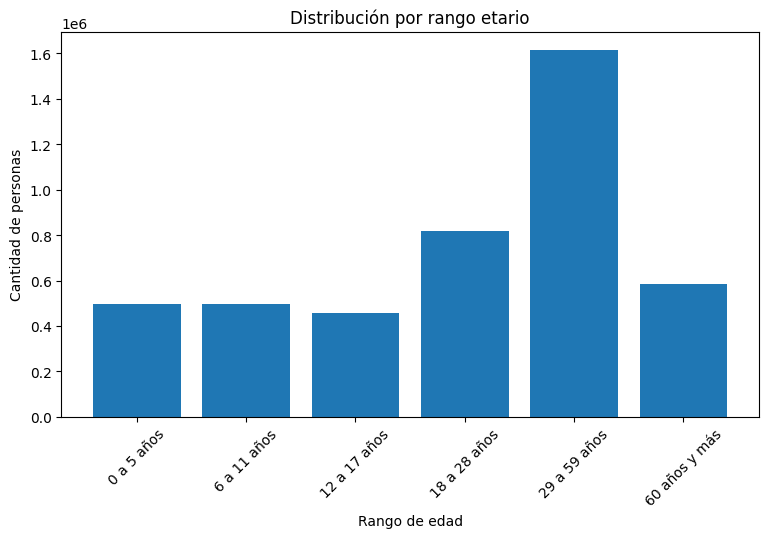

In [0]:
pdf_edad = df_edad.toPandas()

plt.figure(figsize=(9,5))
plt.bar(pdf_edad["rango_edad"], pdf_edad["count"])
plt.xlabel("Rango de edad")
plt.ylabel("Cantidad de personas")
plt.title("Distribución por rango etario")
plt.xticks(rotation=45)
plt.show()

### 4. Distribución por sexo
Se analiza la proporción de registros según sexo, para complementar la caracterización demográfica del dataset.

In [0]:
df_sexo = (
    df_sisben.groupBy("PER001")
      .count()
      .orderBy("PER001")
      .withColumn(
          "sexo",
          F.when(F.col("PER001") == 1, "Hombre")
           .when(F.col("PER001") == 2, "Mujer")
      )
)

display(df_sexo)

PER001,count,sexo
1,2196557,Hombre
2,2269398,Mujer


### 5. Comportamiento del indicador proxy de pobreza multidimensional
Se analiza la distribución del indicador h_5, que funciona como variable binaria, para identificar la proporción de personas que presentan esta condición.

In [0]:
df_h5 = (
    df_sisben.groupBy("H_5")
      .count()
      .orderBy("H_5")
)

display(df_h5)

H_5,count
0,2712913
1,1753042


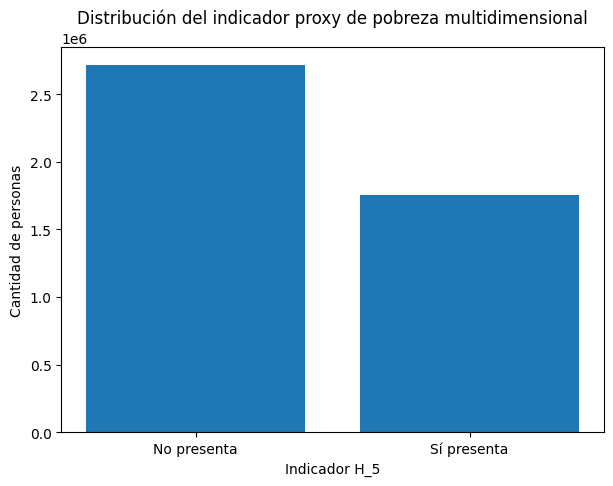

In [0]:
pdf_h5 = df_h5.toPandas()
pdf_h5["h5_label"] = pdf_h5["H_5"].map({0: "No presenta", 1: "Sí presenta"})

plt.figure(figsize=(7,5))
plt.bar(pdf_h5["h5_label"], pdf_h5["count"])
plt.xlabel("Indicador H_5")
plt.ylabel("Cantidad de personas")
plt.title("Distribución del indicador proxy de pobreza multidimensional")
plt.show()

### 6. Incidencia de privaciones educativas
Se calculan los promedios de las privaciones educativas principales, con el objetivo de identificar qué carencias relacionadas con educación tienen mayor presencia en la población analizada.

In [0]:
df_priv_edu = df_sisben.select(
    F.round(F.avg(F.col("I1").cast("double")), 4).alias("bajo_logro_educativo"),
    F.round(F.avg(F.col("I2").cast("double")), 4).alias("analfabetismo"),
    F.round(F.avg(F.col("I3").cast("double")), 4).alias("inasistencia_escolar"),
    F.round(F.avg(F.col("I4").cast("double")), 4).alias("rezago_escolar")
)

display(df_priv_edu)

bajo_logro_educativo,analfabetismo,inasistencia_escolar,rezago_escolar
0.6878,0.1941,0.0673,0.3062


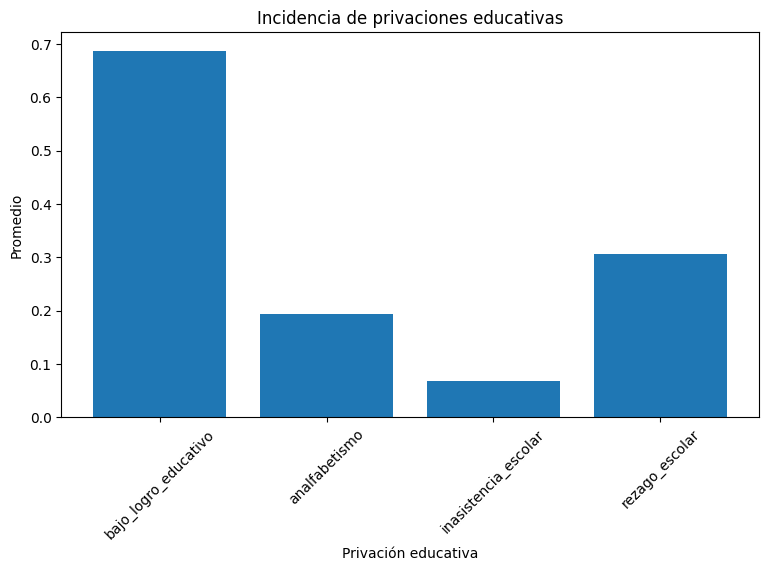

In [0]:
pdf_priv_edu = df_priv_edu.toPandas().T.reset_index()
pdf_priv_edu.columns = ["privacion", "promedio"]

plt.figure(figsize=(9,5))
plt.bar(pdf_priv_edu["privacion"], pdf_priv_edu["promedio"])
plt.xlabel("Privación educativa")
plt.ylabel("Promedio")
plt.title("Incidencia de privaciones educativas")
plt.xticks(rotation=45)
plt.show()

### 7. Comparación general de las privaciones IPM
Se comparan las variables de privación I1 a I15 para reconocer cuáles son las más frecuentes dentro del dataset y cuáles representan mayores niveles de vulnerabilidad.

In [0]:
ipm_cols = [f"I{i}" for i in range(1, 16)]

ranking_priv = []

for c in ipm_cols:
    valor = df_sisben.select(F.avg(F.col(c).cast("double"))).first()[0]
    ranking_priv.append((c, round(float(valor), 4) if valor is not None else None))

ranking_priv_df = (
    spark.createDataFrame(ranking_priv, ["privacion", "promedio"])
         .orderBy(F.desc("promedio"))
)

display(ranking_priv_df)

privacion,promedio
I8,0.7549
I1,0.6878
I11,0.3823
I12,0.348
I15,0.313
I4,0.3062
I7,0.2976
I13,0.2624
I2,0.1941
I5,0.1764


### 8. Distribución territorial por municipio
Se analiza la cantidad de registros por municipio para identificar en qué territorios se concentra la población del dataset y reconocer diferencias en la cobertura de la base.

In [0]:
df_municipio = (
    df_sisben.groupBy("Cod_mpio")
      .count()
      .orderBy(F.desc("count"))
)

display(df_municipio)

Cod_mpio,count
23001,11014
47245,10679
13430,10656
44847,10621
13442,10256
23417,10237
13244,9935
23815,9714
44001,9701
19318,9662


### 9. Vulnerabilidad territorial por municipio
Se calcula el promedio del indicador H_5 por municipio, con el fin de identificar diferencias territoriales en la vulnerabilidad y reconocer qué municipios presentan mayores niveles relativos de pobreza multidimensional proxy.

In [0]:
df_h5_mpio = (
    df_sisben.groupBy("Cod_mpio")
      .agg(
          F.count("*").alias("cantidad_personas"),
          F.round(F.avg(F.col("H_5").cast("double")), 4).alias("promedio_h5")
      )
      .filter(F.col("cantidad_personas") >= 20)
      .orderBy(F.desc("promedio_h5"))
)

display(df_h5_mpio)

Cod_mpio,cantidad_personas,promedio_h5
68020,2284,0.8669
54670,3999,0.8652
52696,4480,0.8366
13458,4766,0.7969
27025,7951,0.7812
68773,3237,0.7702
97161,1239,0.7692
52694,3218,0.7669
47205,5173,0.7615
44847,10621,0.7498


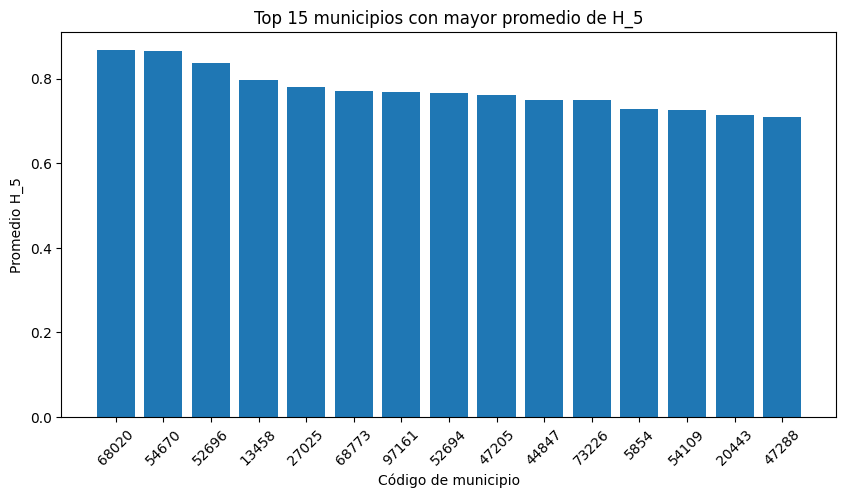

In [0]:
pdf_h5_mpio = df_h5_mpio.limit(15).toPandas()

plt.figure(figsize=(10,5))
plt.bar(pdf_h5_mpio["Cod_mpio"].astype(str), pdf_h5_mpio["promedio_h5"])
plt.xlabel("Código de municipio")
plt.ylabel("Promedio H_5")
plt.title("Top 15 municipios con mayor promedio de H_5")
plt.xticks(rotation=45)
plt.show()

### 10. Comparación por zona
Se compara la distribución de la población y el comportamiento de algunos indicadores de vulnerabilidad según la zona, para explorar diferencias básicas entre cabecera y centro poblado o rural disperso.

In [0]:
df_zona = (
    df_sisben.groupBy("ZONA")
      .agg(
          F.count("*").alias("total_personas"),
          F.round(F.avg(F.col("H_5").cast("double")), 4).alias("promedio_h5"),
          F.round(F.avg(F.col("I1").cast("double")), 4).alias("avg_i1"),
          F.round(F.avg(F.col("I3").cast("double")), 4).alias("avg_i3")
      )
      .orderBy("ZONA")
)

display(df_zona)

ZONA,total_personas,promedio_h5,avg_i1,avg_i3
1,2033926,0.3168,0.5846,0.057
2,2432029,0.4559,0.774,0.0759


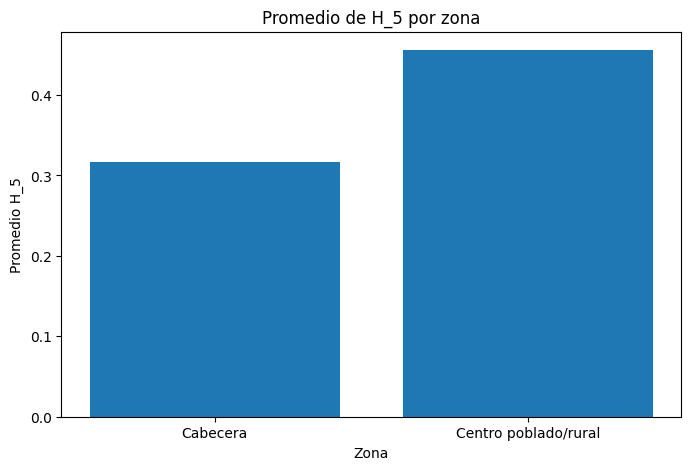

In [0]:
pdf_zona = df_zona.toPandas()
pdf_zona["zona_label"] = pdf_zona["ZONA"].map({1: "Cabecera", 2: "Centro poblado/rural"})

plt.figure(figsize=(8,5))
plt.bar(pdf_zona["zona_label"], pdf_zona["promedio_h5"])
plt.xlabel("Zona")
plt.ylabel("Promedio H_5")
plt.title("Promedio de H_5 por zona")
plt.show()

### 11. Privaciones educativas por grupo SISBÉN
Se comparan las privaciones educativas entre grupos SISBÉN, con el propósito de identificar si los grupos más vulnerables presentan también mayores carencias en dimensiones relacionadas con educación.

In [0]:
df_priv_grupo = (
    df_sisben.groupBy("Grupo")
      .agg(
          F.round(F.avg(F.col("I1").cast("double")), 4).alias("avg_i1"),
          F.round(F.avg(F.col("I2").cast("double")), 4).alias("avg_i2"),
          F.round(F.avg(F.col("I3").cast("double")), 4).alias("avg_i3"),
          F.round(F.avg(F.col("I4").cast("double")), 4).alias("avg_i4")
      )
      .orderBy("Grupo")
)

display(df_priv_grupo)

Grupo,avg_i1,avg_i2,avg_i3,avg_i4
A,0.7721,0.2585,0.1027,0.4246
B,0.6871,0.1758,0.0536,0.2737
C,0.5834,0.1173,0.026,0.1526
D,0.31,0.034,0.005,0.048


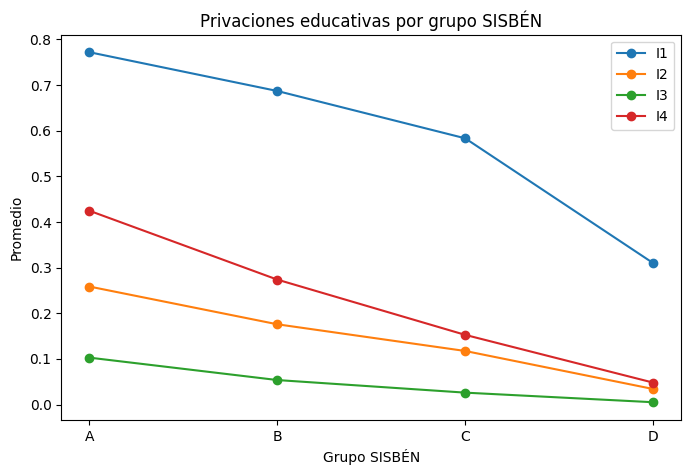

In [0]:
pdf_priv_grupo = df_priv_grupo.toPandas()

plt.figure(figsize=(8,5))
plt.plot(pdf_priv_grupo["Grupo"], pdf_priv_grupo["avg_i1"], marker="o", label="I1")
plt.plot(pdf_priv_grupo["Grupo"], pdf_priv_grupo["avg_i2"], marker="o", label="I2")
plt.plot(pdf_priv_grupo["Grupo"], pdf_priv_grupo["avg_i3"], marker="o", label="I3")
plt.plot(pdf_priv_grupo["Grupo"], pdf_priv_grupo["avg_i4"], marker="o", label="I4")
plt.xlabel("Grupo SISBÉN")
plt.ylabel("Promedio")
plt.title("Privaciones educativas por grupo SISBÉN")
plt.legend()
plt.show()

### 12. Acumulación de privaciones por persona
Se calcula el número total de privaciones acumuladas por cada persona, con el objetivo de identificar niveles de vulnerabilidad múltiple dentro de la población registrada.

In [0]:
df_priv = df_sisben.withColumn(
    "total_privaciones",
    sum(F.coalesce(F.col(c).cast("int"), F.lit(0)) for c in ipm_cols)
)

df_total_priv = (
    df_priv.groupBy("total_privaciones")
           .count()
           .orderBy("total_privaciones")
)

display(df_total_priv)

total_privaciones,count
0,161402
1,351209
2,608102
3,795347
4,796336
5,662611
6,484976
7,309772
8,166961
9,80749


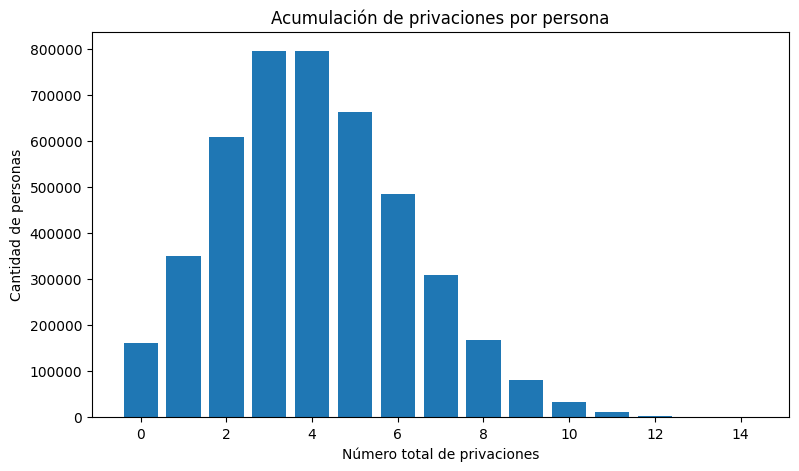

In [0]:
pdf_total_priv = df_total_priv.toPandas()

plt.figure(figsize=(9,5))
plt.bar(pdf_total_priv["total_privaciones"], pdf_total_priv["count"])
plt.xlabel("Número total de privaciones")
plt.ylabel("Cantidad de personas")
plt.title("Acumulación de privaciones por persona")
plt.show()

## Conclusiones del Exploración de Datos

* La población del dataset se concentra principalmente en los grupos más vulnerables del SISBÉN, lo que confirma que la base es útil para analizar condiciones de pobreza y privación social.
* El indicador H_5 muestra que una parte importante de los registros presenta condiciones asociadas a pobreza multidimensional, por lo que resulta pertinente para complementar el análisis del proyecto.
* Entre las privaciones educativas, destacan especialmente bajo logro educativo y rezago escolar, lo que sugiere que las mayores brechas observadas están relacionadas con trayectorias educativas desfavorables.
* La comparación entre las variables de privación evidencia que la vulnerabilidad no se distribuye de manera uniforme: algunas carencias tienen mucha mayor incidencia que otras.
* A nivel territorial, se observan diferencias entre municipios tanto en la cantidad de registros como en el nivel de vulnerabilidad, lo que sugiere que el fenómeno no se comporta de forma homogénea en todo el territorio.
* La comparación por zona muestra una mayor vulnerabilidad en centro poblado/rural disperso frente a cabecera, lo que evidencia una brecha territorial relevante.
* Los grupos SISBÉN con mayor vulnerabilidad también presentan mayores niveles de privaciones educativas, lo que muestra consistencia entre la clasificación socioeconómica y las condiciones observadas en la base.
* Finalmente, la acumulación de privaciones en una misma persona indica que la vulnerabilidad es multidimensional, por lo que no conviene analizarla desde una sola variable aislada.

# Reporte de la Calidad de los Datos 
El reporte de calidad de datos tiene como objetivo identificar la presencia de valores faltantes en variables clave del dataset, con el fin de evaluar su impacto en el análisis y proponer estrategias de tratamiento adecuadas.

### Calidad de datos: valores nulos

Se revisan valores faltantes en variables clave para identificar posibles problemas de calidad de datos.

In [0]:
df_nulos = df_sisben.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_sisben.columns
])

display(df_nulos)

cod_mpio,H_5,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,I14,I15,Grupo,Nivel,Clasificacion,ZONA,llave,CORTE,HOGAR,ORDEN,FEX,PER001,PER002,PER003,PER004,PER005,PER005B,PER006,PER006B,PER007,PER008,PER009,PER010,PER011,PER012,PER013,PER014,PER015,PER016,PER017,PER018,PER019,PER020
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Conteo de nulos en variables clave
Se realiza una revisión específica de algunas variables centrales para el análisis, como el municipio, la clasificación SISBÉN, el indicador proxy de pobreza multidimensional y las privaciones educativas principales.


In [0]:
df_nulos_clave = df_sisben.select(
    F.count("*").alias("total_registros"),
    F.count("Cod_mpio").alias("no_nulos_cod_mpio"),
    (F.count("*") - F.count("Cod_mpio")).alias("nulos_cod_mpio"),
    F.count("Grupo").alias("no_nulos_grupo"),
    (F.count("*") - F.count("Grupo")).alias("nulos_grupo"),
    F.count("Clasificacion").alias("no_nulos_clasificacion"),
    (F.count("*") - F.count("Clasificacion")).alias("nulos_clasificacion"),
    F.count("H_5").alias("no_nulos_h5"),
    (F.count("*") - F.count("H_5")).alias("nulos_h5"),
    F.count("I1").alias("no_nulos_i1"),
    (F.count("*") - F.count("I1")).alias("nulos_i1"),
    F.count("I2").alias("no_nulos_i2"),
    (F.count("*") - F.count("I2")).alias("nulos_i2"),
    F.count("I3").alias("no_nulos_i3"),
    (F.count("*") - F.count("I3")).alias("nulos_i3"),
    F.count("I4").alias("no_nulos_i4"),
    (F.count("*") - F.count("I4")).alias("nulos_i4")
)

display(df_nulos_clave)

total_registros,no_nulos_cod_mpio,nulos_cod_mpio,no_nulos_grupo,nulos_grupo,no_nulos_clasificacion,nulos_clasificacion,no_nulos_h5,nulos_h5,no_nulos_i1,nulos_i1,no_nulos_i2,nulos_i2,no_nulos_i3,nulos_i3,no_nulos_i4,nulos_i4
4465955,4465955,0,4465955,0,4465955,0,4465955,0,4465955,0,4465955,0,4465955,0,4465955,0


### Registros duplicados exactos
Se verifica si existen filas completamente duplicadas dentro del dataset, lo que permitiría identificar problemas de carga o replicación de registros.

In [0]:
df_duplicados_exactos = df_sisben.groupBy(df_sisben.columns).count().filter(F.col("count") > 1)

display(df_duplicados_exactos)

cod_mpio,H_5,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,I14,I15,Grupo,Nivel,Clasificacion,ZONA,llave,CORTE,HOGAR,ORDEN,FEX,PER001,PER002,PER003,PER004,PER005,PER005B,PER006,PER006B,PER007,PER008,PER009,PER010,PER011,PER012,PER013,PER014,PER015,PER016,PER017,PER018,PER019,PER020,count


### Reporte de calidad de datos

A partir del análisis de valores faltantes en el dataset de personas registradas en SISBÉN, se identificó un alto nivel de completitud en las variables evaluadas.
El dataset cuenta con un total de **4,465,955** registros. Al revisar los valores nulos tanto a nivel general como en variables clave para el análisis, no se encontraron faltantes en columnas como cod_mpio, Grupo, Clasificacion, H_5, I1, I2, I3 e I4. Esto indica que las variables centrales del estudio presentan una cobertura completa dentro de la base analizada.
Adicionalmente, al verificar la existencia de registros duplicados exactos, no se identificaron filas repetidas en el dataset. Esto sugiere que, al menos desde el punto de vista de duplicidad exacta, la base conserva una estructura consistente y no presenta problemas evidentes de replicación de registros.
En conjunto, estos resultados evidencian que el dataset presenta una buena calidad inicial en términos de completitud e integridad básica, lo cual constituye una ventaja importante para las etapas posteriores de exploración, transformación y análisis territorial.


### Propuesta de tratamiento de datos
Con base en los hallazgos obtenidos, se proponen las siguientes estrategias:
* No aplicar imputación de valores faltantes en las variables clave: Dado que no se identificaron valores nulos en las variables principales del análisis, no es necesario aplicar técnicas de imputación en esta etapa.
* Mantener validaciones de integridad en el pipeline de trabajo: Aunque no se encontraron nulos ni duplicados exactos, se recomienda conservar rutinas de validación durante el procesamiento para asegurar que estas condiciones se mantengan en futuras transformaciones o integraciones con otros datasets.
* Revisar consistencia de variables codificadas: Debido a que varias variables del dataset están representadas mediante códigos numéricos, se recomienda verificar que sus valores se mantengan dentro de los rangos esperados según el diccionario de datos, evitando interpretaciones erróneas.
* Aplicar filtros según el objetivo analítico: Aunque no se requieren limpiezas por nulos o duplicados exactos, sí pueden ser necesarios filtros posteriores dependiendo del análisis, por ejemplo al seleccionar variables específicas, trabajar por municipio o construir indicadores agregados.
* Conservar la estructura original como referencia: Dado que la base presenta buena calidad inicial, es conveniente mantener una copia del dataset original y realizar cualquier transformación sobre versiones derivadas, para garantizar trazabilidad en el proceso analítico.

# Filtros, limpieza y transformación inicial
### Eliminación preventiva de registros duplicados exactos
Aunque en el análisis de calidad no se identificaron duplicados exactos, se aplica esta limpieza básica como medida preventiva para asegurar que cada registro permanezca una sola vez dentro del dataset.


In [0]:
df_sisben_clean = df_sisben.dropDuplicates()

print("Total original:", df_sisben.count())
print("Total limpio:", df_sisben_clean.count())

Total original: 4465955
Total limpio: 4465955


### Estandarización de variables categóricas
Se realiza una limpieza básica sobre variables categóricas como Grupo y Clasificacion, con el fin de evitar inconsistencias por diferencias en mayúsculas, espacios o formato.

In [0]:
df_sisben_clean = df_sisben_clean.withColumn(
    "Grupo",
    F.upper(F.trim(F.col("Grupo")))
)

df_sisben_clean = df_sisben_clean.withColumn(
    "Clasificacion",
    F.upper(F.trim(F.col("Clasificacion")))
)

### Tratamiento inicial de valores faltantes en variables categóricas
Aunque no se identificaron nulos relevantes en las variables principales, se propone un tratamiento preventivo en variables categóricas clave para conservar registros en caso de futuras integraciones o transformaciones.

In [0]:
df_sisben_clean = df_sisben_clean.fillna({
    "Grupo": "SIN INFORMACION",
    "Clasificacion": "SIN INFORMACION"
})

### Validación de valores binarios en pobreza multidimensional y privaciones
Se realiza un filtrado inicial para conservar únicamente los registros cuyos valores en H_5 e I1 a I15 pertenezcan al dominio esperado, es decir, 0 o 1.

In [0]:
ipm_cols = ["H_5"] + [f"I{i}" for i in range(1, 16)]

condicion_valida = None

for c in ipm_cols:
    cond = (F.col(c).isin(0, 1)) | F.col(c).isNull()
    condicion_valida = cond if condicion_valida is None else (condicion_valida & cond)

df_sisben_clean = df_sisben_clean.filter(condicion_valida)

### Validación básica de variables codificadas
Se filtran registros que no cumplan con los rangos esperados en algunas variables categóricas codificadas, como sexo, rango de edad y zona.

In [0]:
df_sisben_clean = df_sisben_clean.filter(
    F.col("PER001").isin(1, 2) &
    F.col("PER002").isin(1, 2, 3, 4, 5, 6) &
    F.col("ZONA").isin(1, 2)
)

### Creación de variable de número total de privaciones
Se genera una variable que resume cuántas privaciones acumula cada persona, lo que facilita el análisis de vulnerabilidad multidimensional.

In [0]:
df_sisben_clean = df_sisben_clean.withColumn(
    "TOTAL_PRIVACIONES",
    sum(F.coalesce(F.col(c).cast("int"), F.lit(0)) for c in ipm_cols)
)

df_sisben_clean.select("TOTAL_PRIVACIONES").show(20)

+-----------------+
|TOTAL_PRIVACIONES|
+-----------------+
|                9|
|                1|
|                3|
|                4|
|                1|
|                4|
|                2|
|                3|
|                2|
|                5|
|                8|
|                7|
|                3|
|                0|
|                1|
|                2|
|                3|
|                4|
|                4|
|                3|
+-----------------+
only showing top 20 rows


### Creación de etiquetas para rango de edad
Dado que PER002 no representa edad exacta sino grupos etarios codificados, se construye una variable categórica más interpretable para facilitar el análisis posterior.

In [0]:
df_sisben_clean = df_sisben_clean.withColumn(
    "RANGO_EDAD",
    F.when(F.col("PER002") == 1, "0 A 5 ANOS")
     .when(F.col("PER002") == 2, "6 A 11 ANOS")
     .when(F.col("PER002") == 3, "12 A 17 ANOS")
     .when(F.col("PER002") == 4, "18 A 28 ANOS")
     .when(F.col("PER002") == 5, "29 A 59 ANOS")
     .when(F.col("PER002") == 6, "60 ANOS Y MAS")
)

### Creación de etiquetas para zona
Se transforma la variable ZONA en una categoría más legible, con el fin de facilitar comparaciones territoriales posteriores.

In [0]:
df_sisben_clean = df_sisben_clean.withColumn(
    "ZONA_LABEL",
    F.when(F.col("ZONA") == 1, "CABECERA")
     .when(F.col("ZONA") == 2, "CENTRO POBLADO / RURAL DISPERSO")
)

### Filtrado de registros para análisis territoriales
Para los análisis por municipio, se conservan únicamente los registros que cuentan con información territorial válida, garantizando consistencia en los resultados agregados.

In [0]:
df_sisben_geo = df_sisben_clean.filter(
    F.col("cod_mpio").isNotNull()
)

print("Total con información geográfica:", df_sisben_geo.count())

Total con información geográfica: 4465955


### Filtrado de municipios con baja representatividad
Para ciertos análisis territoriales comparativos, se genera un subconjunto que conserva únicamente municipios con un número mínimo de registros, evitando interpretaciones sobre territorios con muy poca información.

In [0]:
df_mpios_validos = (
    df_sisben_geo.groupBy("cod_mpio")
      .count()
      .filter(F.col("count") >= 20)
      .select("cod_mpio")
)

df_sisben_geo_filtrado = df_sisben_geo.join(df_mpios_validos, on="cod_mpio", how="inner")

print("Total registros en municipios con al menos 20 observaciones:", df_sisben_geo_filtrado.count())

Total registros en municipios con al menos 20 observaciones: 4465955


En esta fase se realizaron procesos iniciales de filtrado, limpieza y transformación de los datos con el fin de mejorar su consistencia y facilitar su uso en análisis posteriores. Se aplicó una depuración preventiva de duplicados, se estandarizaron variables categóricas, se validaron rangos en variables codificadas y se construyeron variables derivadas como el total de privaciones, etiquetas de rango de edad y categorías de zona. Adicionalmente, se definieron subconjuntos orientados al análisis territorial, permitiendo contar con una base más interpretable y preparada para las siguientes etapas del proyecto.